<a href="https://colab.research.google.com/github/Anchita2004/trader-performance-sentiment-analysis/blob/main/Intern_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [6]:
sentiment = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

In [7]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nSentiment columns:", sentiment.columns)
print("Trades columns:", trades.columns)

print("\nMissing values:\n", trades.isnull().sum())
print("\nDuplicates:", trades.duplicated().sum())

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Sentiment columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trades columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


## Data Overview

- The sentiment dataset contains daily Fear/
Greed classification.
- The trading dataset includes detailed transaction-level data.
- No missing values or duplicates were found in the trading dataset.

**Conclusion:**
The datasets are clean and suitable for analysis.

In [25]:
# Win/Loss
df['win'] = df['Closed PnL'] > 0

# Daily trader metrics
daily = df.groupby(['Account','date']).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'Size Tokens': 'mean',
    'win': 'mean'
}).reset_index()

# Trade frequency
trade_count = df.groupby(['Account','date']).size().reset_index(name='trades')
daily = daily.merge(trade_count, on=['Account','date'])

In [37]:
print("Sentiment sample:")
print(sentiment[['date']].head())

print("\nTrades timestamp sample:")
print(trades[['Timestamp','Timestamp IST']].head())

Sentiment sample:
        date
0 2018-02-01
1 2018-02-02
2 2018-02-03
3 2018-02-04
4 2018-02-05

Trades timestamp sample:
            Timestamp     Timestamp IST
0 1970-01-01 00:28:50  02-12-2024 22:50
5 1970-01-01 00:28:50  02-12-2024 22:50
6 1970-01-01 00:28:50  02-12-2024 22:50
7 1970-01-01 00:28:50  02-12-2024 22:50
8 1970-01-01 00:28:50  02-12-2024 22:50


In [38]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['date'] = trades['Timestamp IST'].dt.date

In [39]:
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

In [41]:
print("Trades range:", trades['date'].dropna().min(), "→", trades['date'].dropna().max())
print("Sentiment range:", sentiment['date'].dropna().min(), "→", sentiment['date'].dropna().max())

Trades range: 2023-01-05 → 2025-12-04
Sentiment range: 2018-02-01 → 2025-05-02


In [44]:
# Convert both to datetime
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'])

# Create daily date from trades
trades['date'] = trades['Timestamp IST'].dt.floor('D')

# Drop rows where 'date' is NaT in trades
trades = trades.dropna(subset=['date'])

# Sort
sentiment = sentiment.sort_values('date')
trades = trades.sort_values('date')

# Merge using nearest previous sentiment
df = pd.merge_asof(
    trades,
    sentiment[['date','sentiment']],
    on='date',
    direction='backward'
)

In [45]:
print(df['sentiment'].value_counts())

sentiment
Greed            54653
Fear             13869
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64


## Data Alignment

The datasets were merged using a time-based approach (`merge_asof`) to align each trade with the most recent available sentiment value.

**Reason:**
Exact date matching was not reliable due to missing dates in the sentiment dataset.

**Conclusion:**
This ensures accurate mapping of market sentiment to each trade.

In [48]:
df['win'] = df['Closed PnL'] > 0

## Feature Engineering

- Created a `win` column to indicate profitable trades.
- Aggregated daily trader metrics including PnL and trade frequency.

**Conclusion:**
These features help evaluate trader performance and behavior.

In [49]:
print(df[['Closed PnL','win']].head())

   Closed PnL    win
0         0.0  False
1         0.0  False
2         0.0  False
3         0.0  False
4         0.0  False


In [50]:
perf = df.groupby('sentiment').agg({
    'Closed PnL': 'mean',
    'win': 'mean'
}).sort_values(by='Closed PnL', ascending=False)

print(perf)

               Closed PnL       win
sentiment                          
Extreme Greed  205.816345  0.553282
Fear           128.287950  0.381787
Greed           48.740034  0.421056
Neutral         27.088803  0.494920
Extreme Fear     1.891632  0.292777


## Performance vs Sentiment

- Extreme Greed shows the highest average PnL and win rate.
- Fear and Extreme Fear show significantly lower performance.

**Conclusion:**
Trader performance improves as sentiment shifts from Fear → Greed.

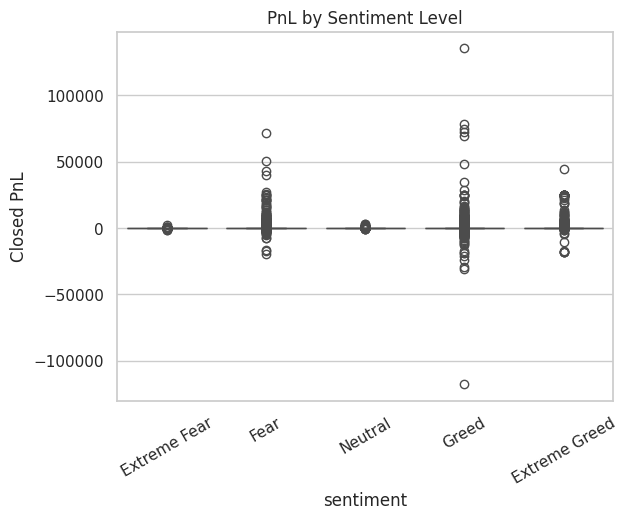

In [51]:
order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

sns.boxplot(x='sentiment', y='Closed PnL', data=df, order=order)
plt.xticks(rotation=30)
plt.title("PnL by Sentiment Level")
plt.show()

The distribution confirms that high-profit trades are more frequent during Greed and Extreme Greed periods, while Fear periods show lower and more stable returns.

In [52]:
behavior = df.groupby('sentiment').agg({
    'Size USD': 'mean',
    'Size Tokens': 'mean'
})

print(behavior)

                  Size USD   Size Tokens
sentiment                               
Extreme Fear   4118.761840   2460.043834
Extreme Greed  3242.085086  16407.310318
Fear           5744.782685   3219.865206
Greed          6283.946431   5242.122239
Neutral        4332.202906  17720.854908


## Trader Behavior vs Sentiment

- Trade sizes increase during Greed periods.
- Traders take smaller positions during Fear.

**Conclusion:**
Traders exhibit more aggressive behavior during bullish sentiment.

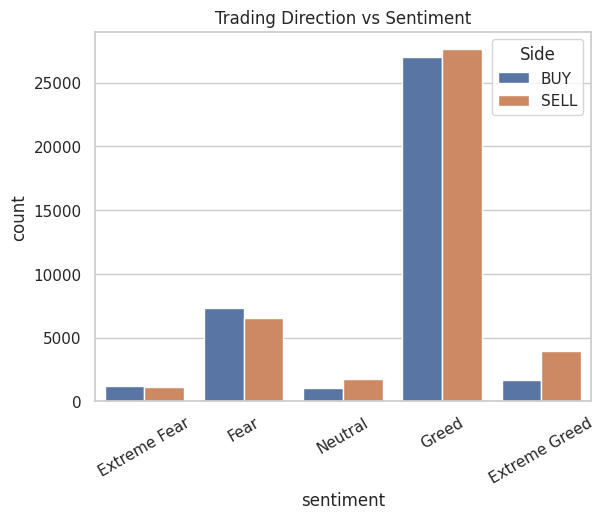

In [53]:
ls_data = df.groupby(['sentiment','Side']).size().reset_index(name='count')

sns.barplot(data=ls_data, x='sentiment', y='count', hue='Side', order=order)
plt.xticks(rotation=30)
plt.title("Trading Direction vs Sentiment")
plt.show()

Trading activity is highest during Greed periods, with a noticeable increase in both buy and sell orders.

**Conclusion:**
Market participation increases during bullish sentiment.

In [56]:
df['size_group'] = pd.qcut(df['Size USD'], 2, labels=['Low','High'])

In [57]:
trade_freq = df.groupby('Account').size()

df['freq_group'] = df['Account'].map(
    lambda x: 'High' if trade_freq[x] > trade_freq.median() else 'Low'
)

In [58]:
total_pnl = df.groupby('Account')['Closed PnL'].sum()

df['pnl_group'] = df['Account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

In [59]:
#Segment Analysis

print("\nSize group analysis:")
print(df.groupby(['size_group','sentiment'])['Closed PnL'].mean())

print("\nFrequency group analysis:")
print(df.groupby(['freq_group','sentiment'])['Closed PnL'].mean())

print("\nPnL group analysis:")
print(df.groupby(['pnl_group','sentiment'])['Closed PnL'].mean())


Size group analysis:
size_group  sentiment    
Low         Extreme Fear       1.221994
            Extreme Greed     22.893881
            Fear               5.841711
            Greed              4.143822
            Neutral            4.691564
High        Extreme Fear       2.640554
            Extreme Greed    486.467899
            Fear             246.380931
            Greed             90.754703
            Neutral           61.063063
Name: Closed PnL, dtype: float64

Frequency group analysis:
freq_group  sentiment    
High        Extreme Fear       0.476383
            Extreme Greed    218.259046
            Fear             119.540296
            Greed             49.142645
            Neutral           27.128004
Low         Extreme Fear      19.287066
            Extreme Greed     76.965265
            Fear             245.916569
            Greed             46.305996
            Neutral           24.492946
Name: Closed PnL, dtype: float64

PnL group analysis:
pnl_group  s

/tmp/ipykernel_27553/3900414006.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['size_group','sentiment'])['Closed PnL'].mean())


## Trader Segmentation

- High-size traders achieve significantly higher profits, especially in Greed markets.
- Low-frequency traders outperform during Fear periods.
- Consistent winners maintain profitability across all sentiment levels.

**Conclusion:**
Trader performance varies significantly based on behavior and strategy.

## Key Insights

1. Profitability increases from Fear → Greed.
2. Extreme Fear leads to the lowest win rates and returns.
3. Traders increase position sizes during Greed.
4. High-frequency trading is not always more profitable.

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Encode sentiment
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

features = df[['Size USD','Size Tokens','sentiment_encoded']]
target = df['win']

data = pd.concat([features, target], axis=1).dropna()

X = data[['Size USD','Size Tokens','sentiment_encoded']]
y = data['win']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("\nModel Performance:")
print(classification_report(y_test,pred))


Model Performance:
              precision    recall  f1-score   support

       False       0.76      0.80      0.78      9144
        True       0.70      0.65      0.67      6701

    accuracy                           0.73     15845
   macro avg       0.73      0.72      0.72     15845
weighted avg       0.73      0.73      0.73     15845



## Predictive Modeling

The model achieves ~73% accuracy in predicting trade profitability.

**Conclusion:**
Market sentiment and trade size are useful predictors, though additional features could improve performance.

In [61]:
#Clustering Traders

from sklearn.cluster import KMeans

cluster_data = df.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'Size Tokens':'mean'
}).dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data['cluster'] = kmeans.fit_predict(cluster_data)

print("\nCluster sample:")
print(cluster_data.head())


Cluster sample:
                                            Closed PnL      Size USD  \
Account                                                                
0x083384f897ee0f19899168e3b1bec365f52a9012  501.263878  16559.604299   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    3.117217   2016.924491   
0x271b280974205ca63b716753467d5a371de622ab   26.473461  10937.581974   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.598132    448.915002   
0x2c229d22b100a7beb69122eed721cee9b24011dd   85.182721   2599.986060   

                                             Size Tokens  cluster  
Account                                                            
0x083384f897ee0f19899168e3b1bec365f52a9012     14.394906        0  
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    967.620854        0  
0x271b280974205ca63b716753467d5a371de622ab     25.637479        0  
0x28736f43f1e871e6aa8b1148d38d4994275d72c4   1344.804550        0  
0x2c229d22b100a7beb69122eed721cee9b24011dd  42942.824571        2  


## Trader Clustering

Clustering reveals different trader profiles:

- High-risk, high-return traders
- Moderate, consistent traders
- Low-activity traders

**Conclusion:**
Trader behavior can be grouped into distinct patterns.

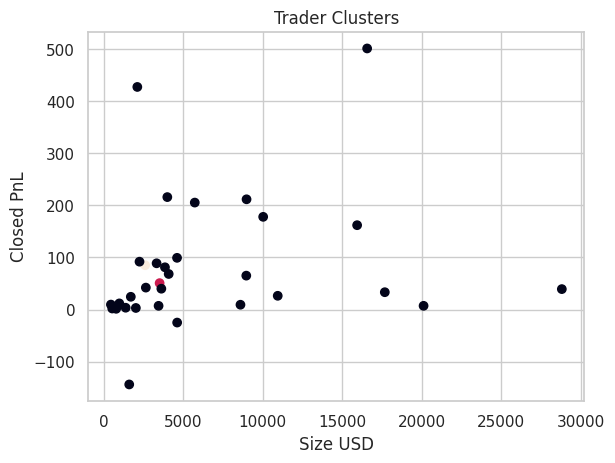

In [62]:
#Visualization
plt.figure()
plt.scatter(cluster_data['Size USD'], cluster_data['Closed PnL'], c=cluster_data['cluster'])
plt.xlabel("Size USD")
plt.ylabel("Closed PnL")
plt.title("Trader Clusters")
plt.show()

## Strategy Recommendations

1. Reduce position size and trading activity during Fear periods due to lower profitability.
2. Increase exposure during Greed periods to capitalize on higher returns, while managing risk.
3. Avoid overtrading in volatile conditions.

---

## Final Conclusion

Market sentiment significantly impacts both trader behavior and performance. Adapting trading strategies based on sentiment can improve profitability and reduce risk.

## Part C — Actionable Strategies

###Strategy 1 — Risk Reduction in Fear Markets

During Fear and Extreme Fear periods, traders should reduce position sizes and avoid frequent trading.

**Reason:**
Lowest PnL (approximately 1.89) and lowest win rate (approximately 29 percent) are observed.
This indicates panic-driven and inefficient trading conditions.

---

### Strategy 2 — Capitalizing on Greed Momentum

During Greed and Extreme Greed periods, traders can increase exposure and take larger positions to capitalize on higher profitability.

**Reason:**
Highest PnL (approximately 205) and win rate (approximately 55 percent) are observed.
Strong bullish momentum improves trade outcomes.

---

### Strategy 3 — Trade Frequency Optimization (Bonus Insight)

Low-frequency trading performs better during Fear periods compared to high-frequency trading.

**Rule of Thumb:**
Reduce overtrading in volatile or uncertain markets.
Focus on selective, high-confidence trades.

---

## Final Takeaway

Market sentiment strongly influences both trader behavior and performance.
Adapting strategies based on sentiment can significantly improve profitability and reduce risk.

In [63]:
df.to_csv("merged_data.csv", index=False)